# Interoperability with Qiskit and OpenQASM

Polypus does not require abandoning already-familiar tools: it accepts Qiskit circuits directly, and it can export and import OpenQASM 2.0, the standard text format for quantum circuits.

## Running a Qiskit circuit directly

`run_quantum_circuit` accepts a Qiskit `QuantumCircuit` as is, with no prior conversion:

In [1]:
import polypus
from qiskit import QuantumCircuit

qc_qiskit = QuantumCircuit(2)
qc_qiskit.h(0)
qc_qiskit.cx(0, 1)
qc_qiskit.measure_all()

result = polypus.run_quantum_circuit(qc_qiskit, shots=1000, infrastructure="local")
print(result.counts[0])

{'00': 496, '11': 504}


The result is the same Bell state from [`01_first_circuit.ipynb`](01_first_circuit.ipynb), only `'00'` and `'11'`, this time built with Qiskit's API instead of with `polypus.Circuit`.

## Exporting to OpenQASM

Any Polypus `Circuit` can be exported to OpenQASM 2.0, the same text format Qiskit uses:

In [2]:
bell = polypus.Circuit(2).h(0).cx(0, 1).measure_all()
print(bell.to_qasm2())

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
measure q -> c;



The result is plain text, readable and portable to any tool that understands OpenQASM 2.0.

## Importing from OpenQASM

`Circuit.from_qasm2` does the reverse, and it also guarantees an exact round trip: exporting, importing, and exporting again produces the same text, byte for byte.

In [3]:
qasm_text = bell.to_qasm2()
reimported_bell = polypus.Circuit.from_qasm2(qasm_text)

print(reimported_bell.to_qasm2() == qasm_text)

True


An imported circuit is a regular `Circuit`: gates can keep being chained onto it like any other.

## Bringing a Qiskit circuit in through QASM

`from_qasm2` also accepts the text Qiskit produces with `qasm2.dumps`, not just Polypus's own. This is useful for converting a Qiskit circuit into a native `Circuit`, for example to keep building it with the method chaining seen in [`00a`](00a_basic_programming.ipynb):

In [4]:
from qiskit import qasm2

qiskit_qasm = qasm2.dumps(qc_qiskit)
native_circuit = polypus.Circuit.from_qasm2(qiskit_qasm)

print(native_circuit.to_qasm2())

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[2];
h q[0];
cx q[0],q[1];
barrier q;
measure q -> c;



On import, Polypus keeps every gate under its own name, `p`, `u1`, `u2`, `u`, and `id` included: only QASM's own `U`/`CX` builtins get normalized to `u`/`cx`. The result is still the same circuit.

Besides OpenQASM, Polypus can export to QIR, a lower-level format aimed at compilers. It is outside the scope of this series, and it is explained in the main README.

## Visualizing a circuit

Polypus does not have its own circuit drawing, but Qiskit's can be used: export to QASM and import back with `qasm2.loads`, the inverse function of `qasm2.dumps` already used above. Qiskit's parser does not recognize some of Polypus's own gates, like `swap`, `cp`, `rzz`, or `rxx`, so it helps to always pass `custom_instructions=qasm2.LEGACY_CUSTOM_INSTRUCTIONS`, which adds them:

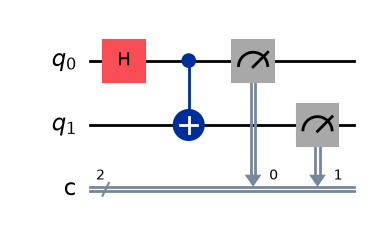

In [5]:
qc_to_draw = qasm2.loads(
    bell.to_qasm2(), custom_instructions=qasm2.LEGACY_CUSTOM_INSTRUCTIONS
)
qc_to_draw.draw("mpl")

The result is a diagram of the circuit: H on qubit 0, CX between the two qubits, and the final measurement of both. It requires `pylatexenc` to be installed; without it, `draw()` still works, but as text instead of an image.

## Summary

This notebook showed several interoperability paths: running a Qiskit circuit directly, exporting a Polypus circuit to OpenQASM, importing both Polypus's own OpenQASM and the one Qiskit generates, and using Qiskit's drawing to visualize a Polypus circuit. Readers who already know Qiskit and want the full mapping, gates, execution, and training included, have the reference guide [`from_qiskit_to_polypus.ipynb`](from_qiskit_to_polypus.ipynb).

The next section covers where these circuits run: locally, or spread across several simulators or QPUs.

## Next step

Continue with: [`03a_local_execution.ipynb`](03a_local_execution.ipynb).